In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('./fake-news/train.csv')

In [3]:
df.head()

,id,title,author,text,label
0,0,House Dem Aide: We Didn’t Even See Comey’s Let...,Darrell Lucus,House Dem Aide: We Didn’t Even See Comey’s Let...,1
1,1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",Daniel J. Flynn,Ever get the feeling your life circles the rou...,0
2,2,Why the Truth Might Get You Fired,Consortiumnews.com,"Why the Truth Might Get You Fired October 29, ...",1
3,3,15 Civilians Killed In Single US Airstrike Hav...,Jessica Purkiss,Videos 15 Civilians Killed In Single US Airstr...,1
4,4,Iranian woman jailed for fictional unpublished...,Howard Portnoy,Print \nAn Iranian woman has been sentenced to...,1


In [8]:
df.shape

(20800, 5)

In [9]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, HashingVectorizer

In [11]:
df = df.dropna()
df.shape

(18285, 5)

In [12]:
messages = df.copy()
messages.reset_index(inplace= True) 
# we reset indices as indices also get dropped along with nan data

In [13]:
messages.loc[6, 'title']

'Benoît Hamon Wins French Socialist Party’s Presidential Nomination - The New York Times'

In [14]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import re
ps = PorterStemmer()

In [17]:
def preprocess(text_col):
    corpus = []
    for i in range(0, len(text_col)):
        review = re.sub('[^a-zA-Z]', ' ', text_col[i])
        review = review.lower()
        review = review.split()
        review = [ps.stem(word) for word in review if word not in stopwords.words('english')]
        review = ' '.join(review)
        corpus.append(review)
    return corpus

In [18]:
corpus = preprocess(text_col= messages['title'])

In [19]:
def vectorize(corpus= None, type= "count", max_features= 5000, ngram_range= (1, 3)):
    if type == "count":
        cv = CountVectorizer(max_features= max_features, ngram_range= ngram_range)
        X = cv.fit_transform(corpus).toarray()
    elif type == "tfidf":
        tf = TfidfVectorizer(max_features= max_features, ngram_range= ngram_range)
        X = tf.fit_transform(corpus).toarray()
    elif type == "hash":
        hsh = HashingVectorizer(max_features= max_features, ngram_range= ngram_range)
        X = hsh.fit_transform(corpus).toarray()
    else:
        return "Wrong Method"
    return X

In [20]:
X = vectorize(corpus= corpus)

In [21]:
X.shape

(18285, 5000)

In [22]:
y = messages['label']

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state= 23)

In [26]:
#MultinomialNB 
from sklearn.naive_bayes import MultinomialNB
classifier = MultinomialNB()

In [27]:
from sklearn.metrics import *
import numpy
import itertools

accuracy: 0.8955523149835946


/Users/nipuntewari/miniforge3/envs/pytch_env/lib/python3.8/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


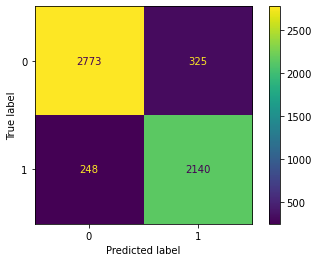

In [30]:
classifier.fit(X_train, y_train)
pred = classifier.predict(X_test)
acc = accuracy_score(y_test, pred)
print(f"accuracy: {acc}")

cm = confusion_matrix(y_test, pred)
plot_confusion_matrix(classifier, X_test, y_test)

In [31]:
#RandomForest
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier()

accuracy: 0.9301859278162595


/Users/nipuntewari/miniforge3/envs/pytch_env/lib/python3.8/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


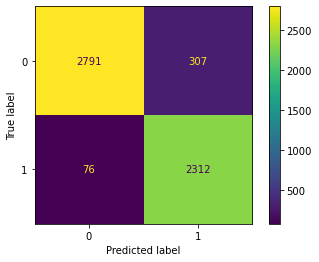

In [32]:
rf_clf.fit(X_train, y_train)
pred = rf_clf.predict(X_test)
acc = accuracy_score(y_test, pred)
print(f"accuracy: {acc}")

cm = confusion_matrix(y_test, pred)
plot_confusion_matrix(rf_clf, X_test, y_test)